🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm

📁 Dosya kontrolü yapılıyor...
   ✅ ON-TARGET: /home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv
   ✅ OFF-TARGET: /home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget.csv

📊 Veriler yükleniyor...
   ✅ ON-TARGET: 39 model yüklendi
   ✅ OFF-TARGET: 936 model yüklendi

🔍 ScFv ID'leri çıkarılıyor...
   ON-TARGET'ta benzersiz ScFv sayısı: 39
   OFF-TARGET'ta benzersiz ScFv sayısı: 39

   Örnek ON-TARGET ScFv ID'ler:
      - scfv_48_1
      - scfv_55_6
      - scfv_73_0

   Örnek OFF-TARGET ScFv ID'ler:
      - scfv_55_9 → CLDN8
      - scfv_39_1 → CLDN34
      - scfv_86_8 → CLDN15

⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...
   Toplam 39 ScFv için worst off-target bulundu

🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...
   ✅ 39 ON-TARGET model birleştirildi

⚖️  Karar algoritması çalıştırılıyor...
   Eşikler:
      - R_spec minimum: 1.15
      - Max Off-Ta

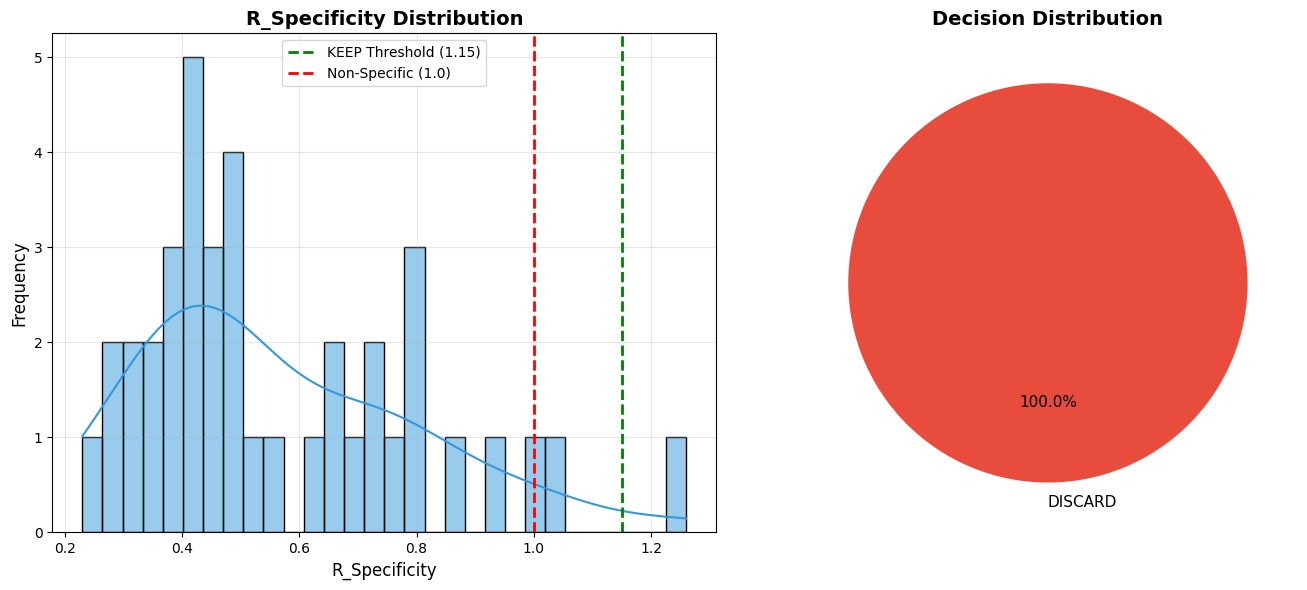


✅ KARAR ALGORİTMASI TAMAMLANDI!

📁 Detaylı rapor için: /home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv
📊 Özet: 0 KEEP, 0 MARGINAL, 39 DISCARD


In [ ]:
# @title 🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm
# @markdown Bu algoritma ON-TARGET ve OFF-TARGET sonuçlarını karşılaştırarak final adayları belirler.

import pandas as pd
import numpy as np
import re
import os

# --- DOSYA YOLLARI ---
CONFIG = {
    "on_target_csv": "/home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv",
    "off_target_csv": "/home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget.csv",
    "final_report": "/home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv",
    
    # --- KARAR EŞİKLERİ ---
    "thresholds": {
        "r_spec_min": 1.15,        # ON-TARGET, OFF-TARGET'tan en az %15 iyi olmalı
        "max_off_score": 0.65,     # OFF-TARGET bu değeri geçerse DISCARD
        "min_on_score": 0.40,      # ON-TARGET bu değerin altındaysa DISCARD
        "excellent_r_spec": 1.50,  # R_spec bu değerin üzerindeyse "Excellent" etiket
        "marginal_r_spec": 1.05    # R_spec bu değerin altındaysa "Marginal"
    }
}

# --- FONKSİYONLAR ---

def extract_scfv_id(sample_id):
    """
    Sample ID'den scfv_X_Y kısmını çıkarır.
    
    Örnekler:
    - scfv_48_1_cldn4 -> scfv_48_1
    - scfv_55_9_vs_cld8_human -> scfv_55_9
    - scfv_0_8_vs_cld18_2_human -> scfv_0_8
    """
    match = re.search(r'(scfv_\d+_\d+)', str(sample_id))
    if match:
        return match.group(1)
    return "Unknown"


def extract_off_target_name(sample_id):
    """
    OFF-TARGET'ın hangi Claudin'e bağlandığını çıkarır.
    
    Örnekler:
    - scfv_55_9_vs_cld8_human -> CLDN8
    - scfv_0_8_vs_cld18_2_human -> CLDN18.2
    """
    match = re.search(r'vs_(cld\d+(?:_\d+)?)', str(sample_id))
    if match:
        cldn = match.group(1).upper().replace('CLD', 'CLDN').replace('_', '.')
        return cldn
    return "Unknown"


def make_decision(on_score, off_score, r_spec, worst_target, thresholds):
    """
    Antikor adayı için final kararı verir.
    
    Returns:
        tuple: (decision, reasons_list, priority)
    """
    reasons = []
    decision = "MARGINAL"
    priority = 2  # 1=KEEP, 2=MARGINAL, 3=DISCARD
    
    # --- DISCARD KURALLARI (En Katı) ---
    
    # 1. Toksik OFF-TARGET Bağlanması
    if off_score > thresholds['max_off_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Toxic Off-Target: {worst_target} (Score={off_score:.3f})")
        return decision, reasons, priority
    
    # 2. Zayıf ON-TARGET Bağlanması
    if on_score < thresholds['min_on_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Weak On-Target Binding (Score={on_score:.3f} < {thresholds['min_on_score']})")
        return decision, reasons, priority
    
    # 3. Non-Specific (OFF-TARGET daha iyi bağlanıyor!)
    if r_spec < 1.0:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Non-Specific: Binds {worst_target} better than CLDN4 (R={r_spec:.2f})")
        return decision, reasons, priority
    
    # --- KEEP KURALLARI (İyi Adaylar) ---
    
    # 1. Mükemmel Özgüllük
    if r_spec >= thresholds['excellent_r_spec']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Excellent Specificity (R={r_spec:.2f})")
    
    # 2. İyi Özgüllük
    elif r_spec >= thresholds['r_spec_min']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Good Specificity (R={r_spec:.2f})")
    
    # --- MARGINAL KURALLARI ---
    
    # Düşük Özgüllük Marjı
    elif r_spec >= thresholds['marginal_r_spec']:
        decision = "MARGINAL"
        priority = 2
        reasons.append(f"⚠️ Low Specificity Margin (R={r_spec:.2f})")
    
    else:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Insufficient Specificity (R={r_spec:.2f} < {thresholds['r_spec_min']})")
    
    # Ek Pozitif Özellikler
    if on_score > 0.70:
        reasons.append(f"💪 Strong On-Target (Score={on_score:.3f})")
    
    if off_score < 0.30:
        reasons.append(f"🛡️ Low Off-Target Risk (Max={off_score:.3f})")
    
    return decision, reasons, priority


# --- ANA AKIŞ ---
print("="*80)
print("🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm")
print("="*80)

# 1. Dosya Kontrolü
print("\n📁 Dosya kontrolü yapılıyor...")
for key, path in [("ON-TARGET", CONFIG["on_target_csv"]), 
                   ("OFF-TARGET", CONFIG["off_target_csv"])]:
    if os.path.exists(path):
        print(f"   ✅ {key}: {path}")
    else:
        print(f"   ❌ {key} BULUNAMADI: {path}")
        exit(1)

# 2. Verileri Yükle
print("\n📊 Veriler yükleniyor...")
try:
    df_on = pd.read_csv(CONFIG["on_target_csv"])
    df_off = pd.read_csv(CONFIG["off_target_csv"])
    print(f"   ✅ ON-TARGET: {len(df_on)} model yüklendi")
    print(f"   ✅ OFF-TARGET: {len(df_off)} model yüklendi")
except Exception as e:
    print(f"   ❌ HATA: {e}")
    exit(1)

# 3. ScFv ID'lerini Çıkar
print("\n🔍 ScFv ID'leri çıkarılıyor...")
df_on['ScFv_ID'] = df_on['Sample_ID'].apply(extract_scfv_id)
df_off['ScFv_ID'] = df_off['Sample_ID'].apply(extract_scfv_id)
df_off['Off_Target_CLDN'] = df_off['Sample_ID'].apply(extract_off_target_name)

print(f"   ON-TARGET'ta benzersiz ScFv sayısı: {df_on['ScFv_ID'].nunique()}")
print(f"   OFF-TARGET'ta benzersiz ScFv sayısı: {df_off['ScFv_ID'].nunique()}")

# Örnek ID'ler göster
print(f"\n   Örnek ON-TARGET ScFv ID'ler:")
for sid in df_on['ScFv_ID'].head(3).tolist():
    print(f"      - {sid}")

print(f"\n   Örnek OFF-TARGET ScFv ID'ler:")
for sid, cldn in zip(df_off['ScFv_ID'].head(3), df_off['Off_Target_CLDN'].head(3)):
    print(f"      - {sid} → {cldn}")

# 4. Her ScFv için EN KÖTÜ Off-Target'ı Bul
print("\n⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...")
worst_off_targets = df_off.sort_values('Scientific_Score', ascending=False).drop_duplicates('ScFv_ID')
worst_off_targets = worst_off_targets[['ScFv_ID', 'Sample_ID', 'Off_Target_CLDN', 'Scientific_Score']]
worst_off_targets.rename(columns={
    'Scientific_Score': 'Max_Off_Score',
    'Sample_ID': 'Worst_Off_Sample',
    'Off_Target_CLDN': 'Worst_Off_Target'
}, inplace=True)

print(f"   Toplam {len(worst_off_targets)} ScFv için worst off-target bulundu")

# 5. ON-TARGET ile Birleştir
print("\n🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...")
merged = pd.merge(df_on, worst_off_targets, on='ScFv_ID', how='left')

# OFF-TARGET verisi olmayanları 0 kabul et (güvenli - sadece CLDN4'e test edilmiş)
merged['Max_Off_Score'] = merged['Max_Off_Score'].fillna(0.0)
merged['Worst_Off_Target'] = merged['Worst_Off_Target'].fillna("None")
merged['Worst_Off_Sample'] = merged['Worst_Off_Sample'].fillna("N/A")

print(f"   ✅ {len(merged)} ON-TARGET model birleştirildi")
unmatched = merged['Max_Off_Score'].eq(0).sum()
if unmatched > 0:
    print(f"   ℹ️  {unmatched} model için OFF-TARGET verisi yok (güvenli kabul edilir)")

# 6. Karar Algoritmasını Çalıştır
print("\n⚖️  Karar algoritması çalıştırılıyor...")
print(f"   Eşikler:")
print(f"      - R_spec minimum: {CONFIG['thresholds']['r_spec_min']}")
print(f"      - Max Off-Target score: {CONFIG['thresholds']['max_off_score']}")
print(f"      - Min On-Target score: {CONFIG['thresholds']['min_on_score']}")

results = []
for _, row in merged.iterrows():
    scfv_id = row['ScFv_ID']
    s_on = row['Scientific_Score']
    s_off = row['Max_Off_Score']
    
    # R_spec Hesapla
    if s_off < 0.01:
        r_spec = 100.0  # Off-target yoksa çok güvenli
    else:
        r_spec = s_on / s_off
    
    # Karar Ver
    decision, reasons, priority = make_decision(
        s_on, s_off, r_spec, 
        row['Worst_Off_Target'], 
        CONFIG['thresholds']
    )
    
    # Sonuç Satırı
    res_dict = {
        "ScFv_ID": scfv_id,
        "Decision": decision,
        "Priority": priority,
        "R_Specificity": round(r_spec, 2),
        "Score_CLDN4": round(s_on, 3),
        "Score_Max_Off": round(s_off, 3),
        "Worst_Off_Target": row['Worst_Off_Target'],
        "Worst_Off_Sample": row['Worst_Off_Sample'],
        "Decision_Reasons": "; ".join(reasons),
        # ON-TARGET Detayları
        "CLDN4_Matrix_iPTM": round(row.get('Matrix_iPTM', 0), 3),
        "CLDN4_Matrix_PAE": round(row.get('Matrix_PAE', 0), 3),
        "CLDN4_Affinity_dG": round(row.get('Affinity_dG', 0), 3),
        "CLDN4_pTM": round(row.get('pTM', 0), 3),
        "CLDN4_Disorder": round(row.get('Fraction_Disordered', 0), 3),
        # Orijinal Sample ID
        "Original_Sample_ID": row['Sample_ID']
    }
    results.append(res_dict)

# 7. Sonuçları Raporla
final_df = pd.DataFrame(results)

# Sıralama: Priority -> R_Specificity (azalan)
final_df.sort_values(by=['Priority', 'R_Specificity'], ascending=[True, False], inplace=True)

# Output dizinini oluştur
output_dir = os.path.dirname(CONFIG["final_report"])
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n📁 Output dizini oluşturuldu: {output_dir}")

# Kaydet
final_df.to_csv(CONFIG["final_report"], index=False)

# Özet İstatistikler
print("\n" + "="*80)
print("📊 KARAR ÖZETİ")
print("="*80)
decision_counts = final_df['Decision'].value_counts()
for decision, count in decision_counts.items():
    pct = count / len(final_df) * 100
    print(f"   {decision}: {count} aday ({pct:.1f}%)")

print(f"\nToplam Değerlendirilen: {len(final_df)} ScFv")

# En İyi 15 Adayı Göster
print("\n" + "="*80)
print("🏆 EN İYİ 15 ADAY (KEEP)")
print("="*80)
display_cols = ['ScFv_ID', 'Decision', 'R_Specificity', 'Score_CLDN4', 
                'Score_Max_Off', 'Worst_Off_Target', 'Decision_Reasons']
keep_candidates = final_df[final_df['Decision'] == 'KEEP']
if len(keep_candidates) > 0:
    print(keep_candidates[display_cols].head(15).to_string(index=False))
else:
    print("   ⚠️  KEEP kategorisinde aday bulunamadı!")

# MARGINAL Adayları Göster
print("\n" + "="*80)
print("⚠️  MARGINAL ADAYLAR (Sınır Durumları)")
print("="*80)
marginal_candidates = final_df[final_df['Decision'] == 'MARGINAL']
if len(marginal_candidates) > 0:
    print(marginal_candidates[display_cols].head(10).to_string(index=False))
else:
    print("   ℹ️  Marginal aday yok")

# DISCARD Nedenleri Analizi
print("\n" + "="*80)
print("❌ DISCARD NEDENLERİ ANALİZİ")
print("="*80)
discard_df = final_df[final_df['Decision'] == 'DISCARD']
if len(discard_df) > 0:
    # Nedenleri kategorize et
    toxic_count = discard_df['Decision_Reasons'].str.contains('Toxic Off-Target').sum()
    weak_count = discard_df['Decision_Reasons'].str.contains('Weak On-Target').sum()
    nonspecific_count = discard_df['Decision_Reasons'].str.contains('Non-Specific').sum()
    insufficient_count = discard_df['Decision_Reasons'].str.contains('Insufficient Specificity').sum()
    
    print(f"   Toxic Off-Target: {toxic_count}")
    print(f"   Weak On-Target: {weak_count}")
    print(f"   Non-Specific: {nonspecific_count}")
    print(f"   Insufficient Specificity: {insufficient_count}")
    
    # En kötü 5 örnek
    print(f"\n   En Kötü 5 DISCARD Örneği:")
    worst_5 = discard_df.sort_values('R_Specificity').head(5)
    print(worst_5[display_cols].to_string(index=False))

# R_Specificity Dağılımı
print("\n" + "="*80)
print("📈 R_SPECIFICITY DAĞILIMI")
print("="*80)
print(f"   Minimum: {final_df['R_Specificity'].min():.2f}")
print(f"   25th percentile: {final_df['R_Specificity'].quantile(0.25):.2f}")
print(f"   Median: {final_df['R_Specificity'].median():.2f}")
print(f"   75th percentile: {final_df['R_Specificity'].quantile(0.75):.2f}")
print(f"   Maximum: {final_df['R_Specificity'].max():.2f}")
print(f"   Mean: {final_df['R_Specificity'].mean():.2f}")

# En Yüksek R_spec'e Sahip 5 Aday
print("\n" + "="*80)
print("🌟 EN YÜKSEK SPESİFİKLİĞE SAHİP 5 ADAY")
print("="*80)
top_5_spec = final_df.nlargest(5, 'R_Specificity')
print(top_5_spec[display_cols].to_string(index=False))

# Görselleştirme için veri hazırla
print("\n" + "="*80)
print("💾 KAYIT ve GÖRSELLEŞTİRME")
print("="*80)
print(f"✅ Final rapor kaydedildi: {CONFIG['final_report']}")

# Görsel için basit dağılım grafiği
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # R_Specificity Dağılımı
    sns.histplot(final_df['R_Specificity'], bins=30, kde=True, ax=axes[0], color='#3498db')
    axes[0].axvline(CONFIG['thresholds']['r_spec_min'], color='green', 
                    linestyle='--', linewidth=2, label=f"KEEP Threshold ({CONFIG['thresholds']['r_spec_min']})")
    axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Non-Specific (1.0)')
    axes[0].set_xlabel('R_Specificity', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('R_Specificity Distribution', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Decision Dağılımı (Pie Chart)
    decision_colors = {'KEEP': '#2ecc71', 'MARGINAL': '#f39c12', 'DISCARD': '#e74c3c'}
    decision_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                        colors=[decision_colors.get(x, '#95a5a6') for x in decision_counts.index],
                        startangle=90, textprops={'fontsize': 11})
    axes[1].set_ylabel('')
    axes[1].set_title('Decision Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plot_path = CONFIG["final_report"].replace('.csv', '_analysis.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"📊 Analiz grafiği kaydedildi: {plot_path}")
    plt.show()
    
except ImportError:
    print("⚠️  Matplotlib bulunamadı, grafik oluşturulamadı")

print("\n" + "="*80)
print("✅ KARAR ALGORİTMASI TAMAMLANDI!")
print("="*80)
print(f"\n📁 Detaylı rapor için: {CONFIG['final_report']}")
print(f"📊 Özet: {len(keep_candidates)} KEEP, {len(marginal_candidates)} MARGINAL, {len(discard_df)} DISCARD")

## Test 1

🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm

📁 Dosya kontrolü yapılıyor...
   ✅ ON-TARGET: /home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv
   ✅ OFF-TARGET: /home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget.csv

📊 Veriler yükleniyor...
   ✅ ON-TARGET: 39 model yüklendi
   ✅ OFF-TARGET: 936 model yüklendi

🔍 ScFv ID'leri çıkarılıyor...
   ON-TARGET'ta benzersiz ScFv sayısı: 39
   OFF-TARGET'ta benzersiz ScFv sayısı: 39

   Örnek ON-TARGET ScFv ID'ler:
      - scfv_48_1
      - scfv_55_6
      - scfv_73_0

   Örnek OFF-TARGET ScFv ID'ler:
      - scfv_55_9 → CLDN8
      - scfv_39_1 → CLDN34
      - scfv_86_8 → CLDN15

⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...
   Toplam 39 ScFv için worst off-target bulundu

🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...
   ✅ 39 ON-TARGET model birleştirildi

⚖️  Karar algoritması çalıştırılıyor...
   Eşikler:
      - R_spec minimum: 1.15
      - Max Off-Ta

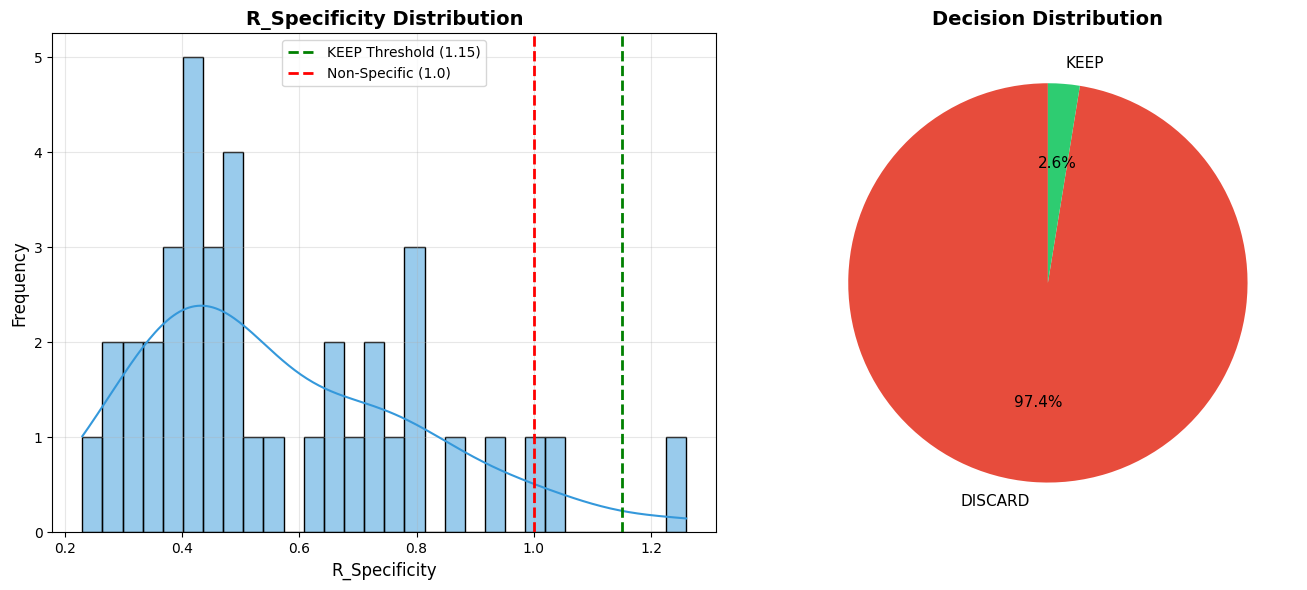


✅ KARAR ALGORİTMASI TAMAMLANDI!

📁 Detaylı rapor için: /home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv
📊 Özet: 1 KEEP, 0 MARGINAL, 38 DISCARD


In [2]:
# @title 🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm
# @markdown Bu algoritma ON-TARGET ve OFF-TARGET sonuçlarını karşılaştırarak final adayları belirler.

import pandas as pd
import numpy as np
import re
import os

# --- DOSYA YOLLARI ---
CONFIG = {
    "on_target_csv": "/home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv",
    "off_target_csv": "/home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget.csv",
    "final_report": "/home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv",
    
    # --- KARAR EŞİKLERİ ---
    "thresholds": {
        "r_spec_min": 1.15,        # ON-TARGET, OFF-TARGET'tan en az %15 iyi olmalı
        "max_off_score": 0.675,    # OFF-TARGET bu değeri geçerse DISCARD 
        "min_on_score": 0.40,      # ON-TARGET bu değerin altındaysa DISCARD
        "excellent_r_spec": 1.50,  # R_spec bu değerin üzerindeyse "Excellent" etiket
        "marginal_r_spec": 1.05    # R_spec bu değerin altındaysa "Marginal"
    }
}

# --- FONKSİYONLAR ---

def extract_scfv_id(sample_id):
    """
    Sample ID'den scfv_X_Y kısmını çıkarır.
    
    Örnekler:
    - scfv_48_1_cldn4 -> scfv_48_1
    - scfv_55_9_vs_cld8_human -> scfv_55_9
    - scfv_0_8_vs_cld18_2_human -> scfv_0_8
    """
    match = re.search(r'(scfv_\d+_\d+)', str(sample_id))
    if match:
        return match.group(1)
    return "Unknown"


def extract_off_target_name(sample_id):
    """
    OFF-TARGET'ın hangi Claudin'e bağlandığını çıkarır.
    
    Örnekler:
    - scfv_55_9_vs_cld8_human -> CLDN8
    - scfv_0_8_vs_cld18_2_human -> CLDN18.2
    """
    match = re.search(r'vs_(cld\d+(?:_\d+)?)', str(sample_id))
    if match:
        cldn = match.group(1).upper().replace('CLD', 'CLDN').replace('_', '.')
        return cldn
    return "Unknown"


def make_decision(on_score, off_score, r_spec, worst_target, thresholds):
    """
    Antikor adayı için final kararı verir.
    
    Returns:
        tuple: (decision, reasons_list, priority)
    """
    reasons = []
    decision = "MARGINAL"
    priority = 2  # 1=KEEP, 2=MARGINAL, 3=DISCARD
    
    # --- DISCARD KURALLARI (En Katı) ---
    
    # 1. Toksik OFF-TARGET Bağlanması
    if off_score > thresholds['max_off_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Toxic Off-Target: {worst_target} (Score={off_score:.3f})")
        return decision, reasons, priority
    
    # 2. Zayıf ON-TARGET Bağlanması
    if on_score < thresholds['min_on_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Weak On-Target Binding (Score={on_score:.3f} < {thresholds['min_on_score']})")
        return decision, reasons, priority
    
    # 3. Non-Specific (OFF-TARGET daha iyi bağlanıyor!)
    if r_spec < 1.0:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Non-Specific: Binds {worst_target} better than CLDN4 (R={r_spec:.2f})")
        return decision, reasons, priority
    
    # --- KEEP KURALLARI (İyi Adaylar) ---
    
    # 1. Mükemmel Özgüllük
    if r_spec >= thresholds['excellent_r_spec']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Excellent Specificity (R={r_spec:.2f})")
    
    # 2. İyi Özgüllük
    elif r_spec >= thresholds['r_spec_min']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Good Specificity (R={r_spec:.2f})")
    
    # --- MARGINAL KURALLARI ---
    
    # Düşük Özgüllük Marjı
    elif r_spec >= thresholds['marginal_r_spec']:
        decision = "MARGINAL"
        priority = 2
        reasons.append(f"⚠️ Low Specificity Margin (R={r_spec:.2f})")
    
    else:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Insufficient Specificity (R={r_spec:.2f} < {thresholds['r_spec_min']})")
    
    # Ek Pozitif Özellikler
    if on_score > 0.70:
        reasons.append(f"💪 Strong On-Target (Score={on_score:.3f})")
    
    if off_score < 0.30:
        reasons.append(f"🛡️ Low Off-Target Risk (Max={off_score:.3f})")
    
    return decision, reasons, priority


# --- ANA AKIŞ ---
print("="*80)
print("🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm")
print("="*80)

# 1. Dosya Kontrolü
print("\n📁 Dosya kontrolü yapılıyor...")
for key, path in [("ON-TARGET", CONFIG["on_target_csv"]), 
                   ("OFF-TARGET", CONFIG["off_target_csv"])]:
    if os.path.exists(path):
        print(f"   ✅ {key}: {path}")
    else:
        print(f"   ❌ {key} BULUNAMADI: {path}")
        exit(1)

# 2. Verileri Yükle
print("\n📊 Veriler yükleniyor...")
try:
    df_on = pd.read_csv(CONFIG["on_target_csv"])
    df_off = pd.read_csv(CONFIG["off_target_csv"])
    print(f"   ✅ ON-TARGET: {len(df_on)} model yüklendi")
    print(f"   ✅ OFF-TARGET: {len(df_off)} model yüklendi")
except Exception as e:
    print(f"   ❌ HATA: {e}")
    exit(1)

# 3. ScFv ID'lerini Çıkar
print("\n🔍 ScFv ID'leri çıkarılıyor...")
df_on['ScFv_ID'] = df_on['Sample_ID'].apply(extract_scfv_id)
df_off['ScFv_ID'] = df_off['Sample_ID'].apply(extract_scfv_id)
df_off['Off_Target_CLDN'] = df_off['Sample_ID'].apply(extract_off_target_name)

print(f"   ON-TARGET'ta benzersiz ScFv sayısı: {df_on['ScFv_ID'].nunique()}")
print(f"   OFF-TARGET'ta benzersiz ScFv sayısı: {df_off['ScFv_ID'].nunique()}")

# Örnek ID'ler göster
print(f"\n   Örnek ON-TARGET ScFv ID'ler:")
for sid in df_on['ScFv_ID'].head(3).tolist():
    print(f"      - {sid}")

print(f"\n   Örnek OFF-TARGET ScFv ID'ler:")
for sid, cldn in zip(df_off['ScFv_ID'].head(3), df_off['Off_Target_CLDN'].head(3)):
    print(f"      - {sid} → {cldn}")

# 4. Her ScFv için EN KÖTÜ Off-Target'ı Bul
print("\n⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...")
worst_off_targets = df_off.sort_values('Scientific_Score', ascending=False).drop_duplicates('ScFv_ID')
worst_off_targets = worst_off_targets[['ScFv_ID', 'Sample_ID', 'Off_Target_CLDN', 'Scientific_Score']]
worst_off_targets.rename(columns={
    'Scientific_Score': 'Max_Off_Score',
    'Sample_ID': 'Worst_Off_Sample',
    'Off_Target_CLDN': 'Worst_Off_Target'
}, inplace=True)

print(f"   Toplam {len(worst_off_targets)} ScFv için worst off-target bulundu")

# 5. ON-TARGET ile Birleştir
print("\n🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...")
merged = pd.merge(df_on, worst_off_targets, on='ScFv_ID', how='left')

# OFF-TARGET verisi olmayanları 0 kabul et (güvenli - sadece CLDN4'e test edilmiş)
merged['Max_Off_Score'] = merged['Max_Off_Score'].fillna(0.0)
merged['Worst_Off_Target'] = merged['Worst_Off_Target'].fillna("None")
merged['Worst_Off_Sample'] = merged['Worst_Off_Sample'].fillna("N/A")

print(f"   ✅ {len(merged)} ON-TARGET model birleştirildi")
unmatched = merged['Max_Off_Score'].eq(0).sum()
if unmatched > 0:
    print(f"   ℹ️  {unmatched} model için OFF-TARGET verisi yok (güvenli kabul edilir)")

# 6. Karar Algoritmasını Çalıştır
print("\n⚖️  Karar algoritması çalıştırılıyor...")
print(f"   Eşikler:")
print(f"      - R_spec minimum: {CONFIG['thresholds']['r_spec_min']}")
print(f"      - Max Off-Target score: {CONFIG['thresholds']['max_off_score']}")
print(f"      - Min On-Target score: {CONFIG['thresholds']['min_on_score']}")

results = []
for _, row in merged.iterrows():
    scfv_id = row['ScFv_ID']
    s_on = row['Scientific_Score']
    s_off = row['Max_Off_Score']
    
    # R_spec Hesapla
    if s_off < 0.01:
        r_spec = 100.0  # Off-target yoksa çok güvenli
    else:
        r_spec = s_on / s_off
    
    # Karar Ver
    decision, reasons, priority = make_decision(
        s_on, s_off, r_spec, 
        row['Worst_Off_Target'], 
        CONFIG['thresholds']
    )
    
    # Sonuç Satırı
    res_dict = {
        "ScFv_ID": scfv_id,
        "Decision": decision,
        "Priority": priority,
        "R_Specificity": round(r_spec, 2),
        "Score_CLDN4": round(s_on, 3),
        "Score_Max_Off": round(s_off, 3),
        "Worst_Off_Target": row['Worst_Off_Target'],
        "Worst_Off_Sample": row['Worst_Off_Sample'],
        "Decision_Reasons": "; ".join(reasons),
        # ON-TARGET Detayları
        "CLDN4_Matrix_iPTM": round(row.get('Matrix_iPTM', 0), 3),
        "CLDN4_Matrix_PAE": round(row.get('Matrix_PAE', 0), 3),
        "CLDN4_Affinity_dG": round(row.get('Affinity_dG', 0), 3),
        "CLDN4_pTM": round(row.get('pTM', 0), 3),
        "CLDN4_Disorder": round(row.get('Fraction_Disordered', 0), 3),
        # Orijinal Sample ID
        "Original_Sample_ID": row['Sample_ID']
    }
    results.append(res_dict)

# 7. Sonuçları Raporla
final_df = pd.DataFrame(results)

# Sıralama: Priority -> R_Specificity (azalan)
final_df.sort_values(by=['Priority', 'R_Specificity'], ascending=[True, False], inplace=True)

# Output dizinini oluştur
output_dir = os.path.dirname(CONFIG["final_report"])
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n📁 Output dizini oluşturuldu: {output_dir}")

# Kaydet
final_df.to_csv(CONFIG["final_report"], index=False)

# Özet İstatistikler
print("\n" + "="*80)
print("📊 KARAR ÖZETİ")
print("="*80)
decision_counts = final_df['Decision'].value_counts()
for decision, count in decision_counts.items():
    pct = count / len(final_df) * 100
    print(f"   {decision}: {count} aday ({pct:.1f}%)")

print(f"\nToplam Değerlendirilen: {len(final_df)} ScFv")

# En İyi 15 Adayı Göster
print("\n" + "="*80)
print("🏆 EN İYİ 15 ADAY (KEEP)")
print("="*80)
display_cols = ['ScFv_ID', 'Decision', 'R_Specificity', 'Score_CLDN4', 
                'Score_Max_Off', 'Worst_Off_Target', 'Decision_Reasons']
keep_candidates = final_df[final_df['Decision'] == 'KEEP']
if len(keep_candidates) > 0:
    print(keep_candidates[display_cols].head(15).to_string(index=False))
else:
    print("   ⚠️  KEEP kategorisinde aday bulunamadı!")

# MARGINAL Adayları Göster
print("\n" + "="*80)
print("⚠️  MARGINAL ADAYLAR (Sınır Durumları)")
print("="*80)
marginal_candidates = final_df[final_df['Decision'] == 'MARGINAL']
if len(marginal_candidates) > 0:
    print(marginal_candidates[display_cols].head(10).to_string(index=False))
else:
    print("   ℹ️  Marginal aday yok")

# DISCARD Nedenleri Analizi
print("\n" + "="*80)
print("❌ DISCARD NEDENLERİ ANALİZİ")
print("="*80)
discard_df = final_df[final_df['Decision'] == 'DISCARD']
if len(discard_df) > 0:
    # Nedenleri kategorize et
    toxic_count = discard_df['Decision_Reasons'].str.contains('Toxic Off-Target').sum()
    weak_count = discard_df['Decision_Reasons'].str.contains('Weak On-Target').sum()
    nonspecific_count = discard_df['Decision_Reasons'].str.contains('Non-Specific').sum()
    insufficient_count = discard_df['Decision_Reasons'].str.contains('Insufficient Specificity').sum()
    
    print(f"   Toxic Off-Target: {toxic_count}")
    print(f"   Weak On-Target: {weak_count}")
    print(f"   Non-Specific: {nonspecific_count}")
    print(f"   Insufficient Specificity: {insufficient_count}")
    
    # En kötü 5 örnek
    print(f"\n   En Kötü 5 DISCARD Örneği:")
    worst_5 = discard_df.sort_values('R_Specificity').head(5)
    print(worst_5[display_cols].to_string(index=False))

# R_Specificity Dağılımı
print("\n" + "="*80)
print("📈 R_SPECIFICITY DAĞILIMI")
print("="*80)
print(f"   Minimum: {final_df['R_Specificity'].min():.2f}")
print(f"   25th percentile: {final_df['R_Specificity'].quantile(0.25):.2f}")
print(f"   Median: {final_df['R_Specificity'].median():.2f}")
print(f"   75th percentile: {final_df['R_Specificity'].quantile(0.75):.2f}")
print(f"   Maximum: {final_df['R_Specificity'].max():.2f}")
print(f"   Mean: {final_df['R_Specificity'].mean():.2f}")

# En Yüksek R_spec'e Sahip 5 Aday
print("\n" + "="*80)
print("🌟 EN YÜKSEK SPESİFİKLİĞE SAHİP 5 ADAY")
print("="*80)
top_5_spec = final_df.nlargest(5, 'R_Specificity')
print(top_5_spec[display_cols].to_string(index=False))

# Görselleştirme için veri hazırla
print("\n" + "="*80)
print("💾 KAYIT ve GÖRSELLEŞTİRME")
print("="*80)
print(f"✅ Final rapor kaydedildi: {CONFIG['final_report']}")

# Görsel için basit dağılım grafiği
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # R_Specificity Dağılımı
    sns.histplot(final_df['R_Specificity'], bins=30, kde=True, ax=axes[0], color='#3498db')
    axes[0].axvline(CONFIG['thresholds']['r_spec_min'], color='green', 
                    linestyle='--', linewidth=2, label=f"KEEP Threshold ({CONFIG['thresholds']['r_spec_min']})")
    axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Non-Specific (1.0)')
    axes[0].set_xlabel('R_Specificity', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('R_Specificity Distribution', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Decision Dağılımı (Pie Chart)
    decision_colors = {'KEEP': '#2ecc71', 'MARGINAL': '#f39c12', 'DISCARD': '#e74c3c'}
    decision_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                        colors=[decision_colors.get(x, '#95a5a6') for x in decision_counts.index],
                        startangle=90, textprops={'fontsize': 11})
    axes[1].set_ylabel('')
    axes[1].set_title('Decision Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plot_path = CONFIG["final_report"].replace('.csv', '_analysis.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"📊 Analiz grafiği kaydedildi: {plot_path}")
    plt.show()
    
except ImportError:
    print("⚠️  Matplotlib bulunamadı, grafik oluşturulamadı")

print("\n" + "="*80)
print("✅ KARAR ALGORİTMASI TAMAMLANDI!")
print("="*80)
print(f"\n📁 Detaylı rapor için: {CONFIG['final_report']}")
print(f"📊 Özet: {len(keep_candidates)} KEEP, {len(marginal_candidates)} MARGINAL, {len(discard_df)} DISCARD")

## Test 2

🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm

📁 Dosya kontrolü yapılıyor...
   ✅ ON-TARGET: /home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv
   ✅ OFF-TARGET: /home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget.csv

📊 Veriler yükleniyor...
   ✅ ON-TARGET: 39 model yüklendi
   ✅ OFF-TARGET: 936 model yüklendi

🔍 ScFv ID'leri çıkarılıyor...
   ON-TARGET'ta benzersiz ScFv sayısı: 39
   OFF-TARGET'ta benzersiz ScFv sayısı: 39

   Örnek ON-TARGET ScFv ID'ler:
      - scfv_48_1
      - scfv_55_6
      - scfv_73_0

   Örnek OFF-TARGET ScFv ID'ler:
      - scfv_55_9 → CLDN8
      - scfv_39_1 → CLDN34
      - scfv_86_8 → CLDN15

⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...
   Toplam 39 ScFv için worst off-target bulundu

🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...
   ✅ 39 ON-TARGET model birleştirildi

⚖️  Karar algoritması çalıştırılıyor...
   Eşikler:
      - R_spec minimum: 1.15
      - Max Off-Ta

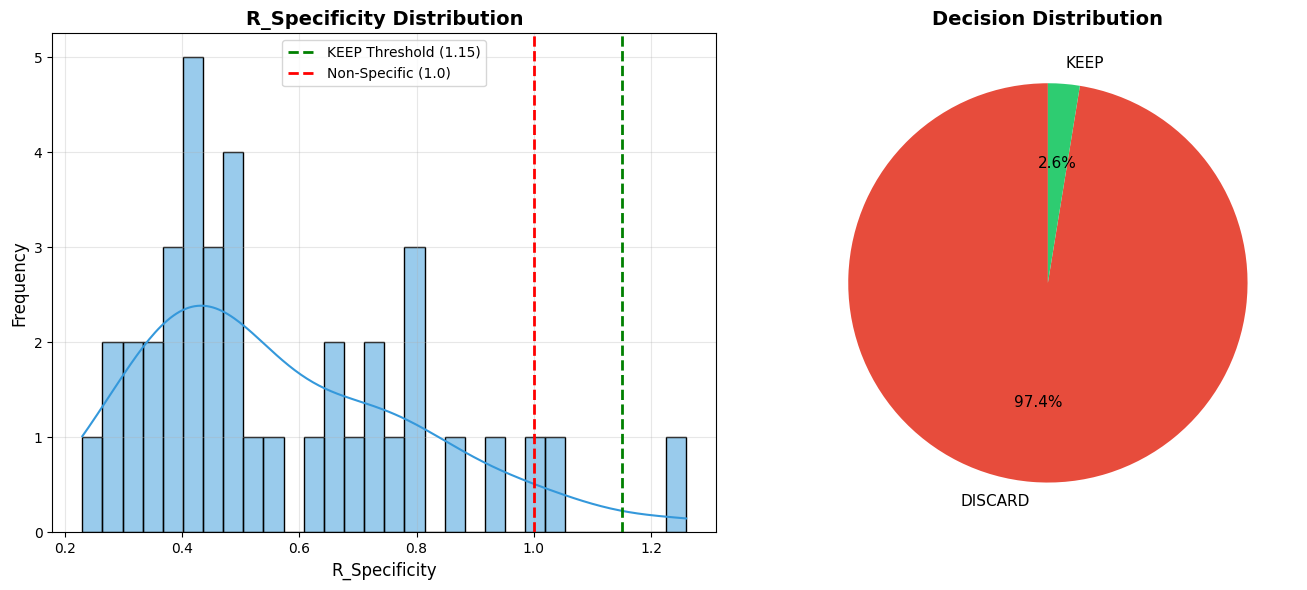


✅ KARAR ALGORİTMASI TAMAMLANDI!

📁 Detaylı rapor için: /home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv
📊 Özet: 1 KEEP, 0 MARGINAL, 38 DISCARD


In [3]:
# @title 🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm
# @markdown Bu algoritma ON-TARGET ve OFF-TARGET sonuçlarını karşılaştırarak final adayları belirler.

import pandas as pd
import numpy as np
import re
import os

# --- DOSYA YOLLARI ---
CONFIG = {
    "on_target_csv": "/home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv",
    "off_target_csv": "/home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget.csv",
    "final_report": "/home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv",
    
    # --- KARAR EŞİKLERİ ---
    "thresholds": {
        "r_spec_min": 1.15,        # ON-TARGET, OFF-TARGET'tan en az %15 iyi olmalı
        "max_off_score": 0.7,    # OFF-TARGET bu değeri geçerse DISCARD 
        "min_on_score": 0.40,      # ON-TARGET bu değerin altındaysa DISCARD
        "excellent_r_spec": 1.50,  # R_spec bu değerin üzerindeyse "Excellent" etiket
        "marginal_r_spec": 1.05    # R_spec bu değerin altındaysa "Marginal"
    }
}

# --- FONKSİYONLAR ---

def extract_scfv_id(sample_id):
    """
    Sample ID'den scfv_X_Y kısmını çıkarır.
    
    Örnekler:
    - scfv_48_1_cldn4 -> scfv_48_1
    - scfv_55_9_vs_cld8_human -> scfv_55_9
    - scfv_0_8_vs_cld18_2_human -> scfv_0_8
    """
    match = re.search(r'(scfv_\d+_\d+)', str(sample_id))
    if match:
        return match.group(1)
    return "Unknown"


def extract_off_target_name(sample_id):
    """
    OFF-TARGET'ın hangi Claudin'e bağlandığını çıkarır.
    
    Örnekler:
    - scfv_55_9_vs_cld8_human -> CLDN8
    - scfv_0_8_vs_cld18_2_human -> CLDN18.2
    """
    match = re.search(r'vs_(cld\d+(?:_\d+)?)', str(sample_id))
    if match:
        cldn = match.group(1).upper().replace('CLD', 'CLDN').replace('_', '.')
        return cldn
    return "Unknown"


def make_decision(on_score, off_score, r_spec, worst_target, thresholds):
    """
    Antikor adayı için final kararı verir.
    
    Returns:
        tuple: (decision, reasons_list, priority)
    """
    reasons = []
    decision = "MARGINAL"
    priority = 2  # 1=KEEP, 2=MARGINAL, 3=DISCARD
    
    # --- DISCARD KURALLARI (En Katı) ---
    
    # 1. Toksik OFF-TARGET Bağlanması
    if off_score > thresholds['max_off_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Toxic Off-Target: {worst_target} (Score={off_score:.3f})")
        return decision, reasons, priority
    
    # 2. Zayıf ON-TARGET Bağlanması
    if on_score < thresholds['min_on_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Weak On-Target Binding (Score={on_score:.3f} < {thresholds['min_on_score']})")
        return decision, reasons, priority
    
    # 3. Non-Specific (OFF-TARGET daha iyi bağlanıyor!)
    if r_spec < 1.0:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Non-Specific: Binds {worst_target} better than CLDN4 (R={r_spec:.2f})")
        return decision, reasons, priority
    
    # --- KEEP KURALLARI (İyi Adaylar) ---
    
    # 1. Mükemmel Özgüllük
    if r_spec >= thresholds['excellent_r_spec']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Excellent Specificity (R={r_spec:.2f})")
    
    # 2. İyi Özgüllük
    elif r_spec >= thresholds['r_spec_min']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Good Specificity (R={r_spec:.2f})")
    
    # --- MARGINAL KURALLARI ---
    
    # Düşük Özgüllük Marjı
    elif r_spec >= thresholds['marginal_r_spec']:
        decision = "MARGINAL"
        priority = 2
        reasons.append(f"⚠️ Low Specificity Margin (R={r_spec:.2f})")
    
    else:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Insufficient Specificity (R={r_spec:.2f} < {thresholds['r_spec_min']})")
    
    # Ek Pozitif Özellikler
    if on_score > 0.70:
        reasons.append(f"💪 Strong On-Target (Score={on_score:.3f})")
    
    if off_score < 0.30:
        reasons.append(f"🛡️ Low Off-Target Risk (Max={off_score:.3f})")
    
    return decision, reasons, priority


# --- ANA AKIŞ ---
print("="*80)
print("🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm")
print("="*80)

# 1. Dosya Kontrolü
print("\n📁 Dosya kontrolü yapılıyor...")
for key, path in [("ON-TARGET", CONFIG["on_target_csv"]), 
                   ("OFF-TARGET", CONFIG["off_target_csv"])]:
    if os.path.exists(path):
        print(f"   ✅ {key}: {path}")
    else:
        print(f"   ❌ {key} BULUNAMADI: {path}")
        exit(1)

# 2. Verileri Yükle
print("\n📊 Veriler yükleniyor...")
try:
    df_on = pd.read_csv(CONFIG["on_target_csv"])
    df_off = pd.read_csv(CONFIG["off_target_csv"])
    print(f"   ✅ ON-TARGET: {len(df_on)} model yüklendi")
    print(f"   ✅ OFF-TARGET: {len(df_off)} model yüklendi")
except Exception as e:
    print(f"   ❌ HATA: {e}")
    exit(1)

# 3. ScFv ID'lerini Çıkar
print("\n🔍 ScFv ID'leri çıkarılıyor...")
df_on['ScFv_ID'] = df_on['Sample_ID'].apply(extract_scfv_id)
df_off['ScFv_ID'] = df_off['Sample_ID'].apply(extract_scfv_id)
df_off['Off_Target_CLDN'] = df_off['Sample_ID'].apply(extract_off_target_name)

print(f"   ON-TARGET'ta benzersiz ScFv sayısı: {df_on['ScFv_ID'].nunique()}")
print(f"   OFF-TARGET'ta benzersiz ScFv sayısı: {df_off['ScFv_ID'].nunique()}")

# Örnek ID'ler göster
print(f"\n   Örnek ON-TARGET ScFv ID'ler:")
for sid in df_on['ScFv_ID'].head(3).tolist():
    print(f"      - {sid}")

print(f"\n   Örnek OFF-TARGET ScFv ID'ler:")
for sid, cldn in zip(df_off['ScFv_ID'].head(3), df_off['Off_Target_CLDN'].head(3)):
    print(f"      - {sid} → {cldn}")

# 4. Her ScFv için EN KÖTÜ Off-Target'ı Bul
print("\n⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...")
worst_off_targets = df_off.sort_values('Scientific_Score', ascending=False).drop_duplicates('ScFv_ID')
worst_off_targets = worst_off_targets[['ScFv_ID', 'Sample_ID', 'Off_Target_CLDN', 'Scientific_Score']]
worst_off_targets.rename(columns={
    'Scientific_Score': 'Max_Off_Score',
    'Sample_ID': 'Worst_Off_Sample',
    'Off_Target_CLDN': 'Worst_Off_Target'
}, inplace=True)

print(f"   Toplam {len(worst_off_targets)} ScFv için worst off-target bulundu")

# 5. ON-TARGET ile Birleştir
print("\n🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...")
merged = pd.merge(df_on, worst_off_targets, on='ScFv_ID', how='left')

# OFF-TARGET verisi olmayanları 0 kabul et (güvenli - sadece CLDN4'e test edilmiş)
merged['Max_Off_Score'] = merged['Max_Off_Score'].fillna(0.0)
merged['Worst_Off_Target'] = merged['Worst_Off_Target'].fillna("None")
merged['Worst_Off_Sample'] = merged['Worst_Off_Sample'].fillna("N/A")

print(f"   ✅ {len(merged)} ON-TARGET model birleştirildi")
unmatched = merged['Max_Off_Score'].eq(0).sum()
if unmatched > 0:
    print(f"   ℹ️  {unmatched} model için OFF-TARGET verisi yok (güvenli kabul edilir)")

# 6. Karar Algoritmasını Çalıştır
print("\n⚖️  Karar algoritması çalıştırılıyor...")
print(f"   Eşikler:")
print(f"      - R_spec minimum: {CONFIG['thresholds']['r_spec_min']}")
print(f"      - Max Off-Target score: {CONFIG['thresholds']['max_off_score']}")
print(f"      - Min On-Target score: {CONFIG['thresholds']['min_on_score']}")

results = []
for _, row in merged.iterrows():
    scfv_id = row['ScFv_ID']
    s_on = row['Scientific_Score']
    s_off = row['Max_Off_Score']
    
    # R_spec Hesapla
    if s_off < 0.01:
        r_spec = 100.0  # Off-target yoksa çok güvenli
    else:
        r_spec = s_on / s_off
    
    # Karar Ver
    decision, reasons, priority = make_decision(
        s_on, s_off, r_spec, 
        row['Worst_Off_Target'], 
        CONFIG['thresholds']
    )
    
    # Sonuç Satırı
    res_dict = {
        "ScFv_ID": scfv_id,
        "Decision": decision,
        "Priority": priority,
        "R_Specificity": round(r_spec, 2),
        "Score_CLDN4": round(s_on, 3),
        "Score_Max_Off": round(s_off, 3),
        "Worst_Off_Target": row['Worst_Off_Target'],
        "Worst_Off_Sample": row['Worst_Off_Sample'],
        "Decision_Reasons": "; ".join(reasons),
        # ON-TARGET Detayları
        "CLDN4_Matrix_iPTM": round(row.get('Matrix_iPTM', 0), 3),
        "CLDN4_Matrix_PAE": round(row.get('Matrix_PAE', 0), 3),
        "CLDN4_Affinity_dG": round(row.get('Affinity_dG', 0), 3),
        "CLDN4_pTM": round(row.get('pTM', 0), 3),
        "CLDN4_Disorder": round(row.get('Fraction_Disordered', 0), 3),
        # Orijinal Sample ID
        "Original_Sample_ID": row['Sample_ID']
    }
    results.append(res_dict)

# 7. Sonuçları Raporla
final_df = pd.DataFrame(results)

# Sıralama: Priority -> R_Specificity (azalan)
final_df.sort_values(by=['Priority', 'R_Specificity'], ascending=[True, False], inplace=True)

# Output dizinini oluştur
output_dir = os.path.dirname(CONFIG["final_report"])
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n📁 Output dizini oluşturuldu: {output_dir}")

# Kaydet
final_df.to_csv(CONFIG["final_report"], index=False)

# Özet İstatistikler
print("\n" + "="*80)
print("📊 KARAR ÖZETİ")
print("="*80)
decision_counts = final_df['Decision'].value_counts()
for decision, count in decision_counts.items():
    pct = count / len(final_df) * 100
    print(f"   {decision}: {count} aday ({pct:.1f}%)")

print(f"\nToplam Değerlendirilen: {len(final_df)} ScFv")

# En İyi 15 Adayı Göster
print("\n" + "="*80)
print("🏆 EN İYİ 15 ADAY (KEEP)")
print("="*80)
display_cols = ['ScFv_ID', 'Decision', 'R_Specificity', 'Score_CLDN4', 
                'Score_Max_Off', 'Worst_Off_Target', 'Decision_Reasons']
keep_candidates = final_df[final_df['Decision'] == 'KEEP']
if len(keep_candidates) > 0:
    print(keep_candidates[display_cols].head(15).to_string(index=False))
else:
    print("   ⚠️  KEEP kategorisinde aday bulunamadı!")

# MARGINAL Adayları Göster
print("\n" + "="*80)
print("⚠️  MARGINAL ADAYLAR (Sınır Durumları)")
print("="*80)
marginal_candidates = final_df[final_df['Decision'] == 'MARGINAL']
if len(marginal_candidates) > 0:
    print(marginal_candidates[display_cols].head(10).to_string(index=False))
else:
    print("   ℹ️  Marginal aday yok")

# DISCARD Nedenleri Analizi
print("\n" + "="*80)
print("❌ DISCARD NEDENLERİ ANALİZİ")
print("="*80)
discard_df = final_df[final_df['Decision'] == 'DISCARD']
if len(discard_df) > 0:
    # Nedenleri kategorize et
    toxic_count = discard_df['Decision_Reasons'].str.contains('Toxic Off-Target').sum()
    weak_count = discard_df['Decision_Reasons'].str.contains('Weak On-Target').sum()
    nonspecific_count = discard_df['Decision_Reasons'].str.contains('Non-Specific').sum()
    insufficient_count = discard_df['Decision_Reasons'].str.contains('Insufficient Specificity').sum()
    
    print(f"   Toxic Off-Target: {toxic_count}")
    print(f"   Weak On-Target: {weak_count}")
    print(f"   Non-Specific: {nonspecific_count}")
    print(f"   Insufficient Specificity: {insufficient_count}")
    
    # En kötü 5 örnek
    print(f"\n   En Kötü 5 DISCARD Örneği:")
    worst_5 = discard_df.sort_values('R_Specificity').head(5)
    print(worst_5[display_cols].to_string(index=False))

# R_Specificity Dağılımı
print("\n" + "="*80)
print("📈 R_SPECIFICITY DAĞILIMI")
print("="*80)
print(f"   Minimum: {final_df['R_Specificity'].min():.2f}")
print(f"   25th percentile: {final_df['R_Specificity'].quantile(0.25):.2f}")
print(f"   Median: {final_df['R_Specificity'].median():.2f}")
print(f"   75th percentile: {final_df['R_Specificity'].quantile(0.75):.2f}")
print(f"   Maximum: {final_df['R_Specificity'].max():.2f}")
print(f"   Mean: {final_df['R_Specificity'].mean():.2f}")

# En Yüksek R_spec'e Sahip 5 Aday
print("\n" + "="*80)
print("🌟 EN YÜKSEK SPESİFİKLİĞE SAHİP 5 ADAY")
print("="*80)
top_5_spec = final_df.nlargest(5, 'R_Specificity')
print(top_5_spec[display_cols].to_string(index=False))

# Görselleştirme için veri hazırla
print("\n" + "="*80)
print("💾 KAYIT ve GÖRSELLEŞTİRME")
print("="*80)
print(f"✅ Final rapor kaydedildi: {CONFIG['final_report']}")

# Görsel için basit dağılım grafiği
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # R_Specificity Dağılımı
    sns.histplot(final_df['R_Specificity'], bins=30, kde=True, ax=axes[0], color='#3498db')
    axes[0].axvline(CONFIG['thresholds']['r_spec_min'], color='green', 
                    linestyle='--', linewidth=2, label=f"KEEP Threshold ({CONFIG['thresholds']['r_spec_min']})")
    axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Non-Specific (1.0)')
    axes[0].set_xlabel('R_Specificity', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('R_Specificity Distribution', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Decision Dağılımı (Pie Chart)
    decision_colors = {'KEEP': '#2ecc71', 'MARGINAL': '#f39c12', 'DISCARD': '#e74c3c'}
    decision_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                        colors=[decision_colors.get(x, '#95a5a6') for x in decision_counts.index],
                        startangle=90, textprops={'fontsize': 11})
    axes[1].set_ylabel('')
    axes[1].set_title('Decision Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plot_path = CONFIG["final_report"].replace('.csv', '_analysis.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"📊 Analiz grafiği kaydedildi: {plot_path}")
    plt.show()
    
except ImportError:
    print("⚠️  Matplotlib bulunamadı, grafik oluşturulamadı")

print("\n" + "="*80)
print("✅ KARAR ALGORİTMASI TAMAMLANDI!")
print("="*80)
print(f"\n📁 Detaylı rapor için: {CONFIG['final_report']}")
print(f"📊 Özet: {len(keep_candidates)} KEEP, {len(marginal_candidates)} MARGINAL, {len(discard_df)} DISCARD")

## Test 3


🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm

📁 Dosya kontrolü yapılıyor...
   ✅ ON-TARGET: /home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv
   ✅ OFF-TARGET: /home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget.csv

📊 Veriler yükleniyor...
   ✅ ON-TARGET: 39 model yüklendi
   ✅ OFF-TARGET: 936 model yüklendi

🔍 ScFv ID'leri çıkarılıyor...
   ON-TARGET'ta benzersiz ScFv sayısı: 39
   OFF-TARGET'ta benzersiz ScFv sayısı: 39

   Örnek ON-TARGET ScFv ID'ler:
      - scfv_48_1
      - scfv_55_6
      - scfv_73_0

   Örnek OFF-TARGET ScFv ID'ler:
      - scfv_55_9 → CLDN8
      - scfv_39_1 → CLDN34
      - scfv_86_8 → CLDN15

⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...
   Toplam 39 ScFv için worst off-target bulundu

🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...
   ✅ 39 ON-TARGET model birleştirildi

⚖️  Karar algoritması çalıştırılıyor...
   Eşikler:
      - R_spec minimum: 1.15
      - Max Off-Ta

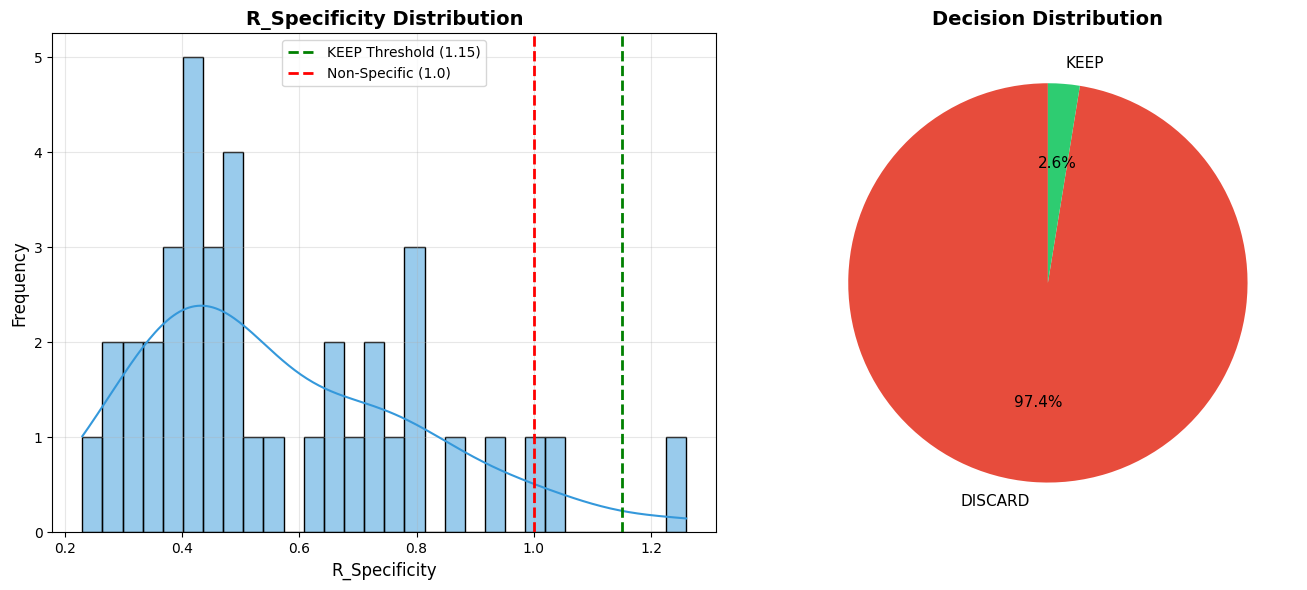


✅ KARAR ALGORİTMASI TAMAMLANDI!

📁 Detaylı rapor için: /home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv
📊 Özet: 1 KEEP, 0 MARGINAL, 38 DISCARD


In [4]:
# @title 🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm
# @markdown Bu algoritma ON-TARGET ve OFF-TARGET sonuçlarını karşılaştırarak final adayları belirler.

import pandas as pd
import numpy as np
import re
import os

# --- DOSYA YOLLARI ---
CONFIG = {
    "on_target_csv": "/home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv",
    "off_target_csv": "/home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget.csv",
    "final_report": "/home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv",
    
    # --- KARAR EŞİKLERİ ---
    "thresholds": {
        "r_spec_min": 1.15,        # ON-TARGET, OFF-TARGET'tan en az %15 iyi olmalı
        "max_off_score": 0.75,    # OFF-TARGET bu değeri geçerse DISCARD 
        "min_on_score": 0.40,      # ON-TARGET bu değerin altındaysa DISCARD
        "excellent_r_spec": 1.50,  # R_spec bu değerin üzerindeyse "Excellent" etiket
        "marginal_r_spec": 1.05    # R_spec bu değerin altındaysa "Marginal"
    }
}

# --- FONKSİYONLAR ---

def extract_scfv_id(sample_id):
    """
    Sample ID'den scfv_X_Y kısmını çıkarır.
    
    Örnekler:
    - scfv_48_1_cldn4 -> scfv_48_1
    - scfv_55_9_vs_cld8_human -> scfv_55_9
    - scfv_0_8_vs_cld18_2_human -> scfv_0_8
    """
    match = re.search(r'(scfv_\d+_\d+)', str(sample_id))
    if match:
        return match.group(1)
    return "Unknown"


def extract_off_target_name(sample_id):
    """
    OFF-TARGET'ın hangi Claudin'e bağlandığını çıkarır.
    
    Örnekler:
    - scfv_55_9_vs_cld8_human -> CLDN8
    - scfv_0_8_vs_cld18_2_human -> CLDN18.2
    """
    match = re.search(r'vs_(cld\d+(?:_\d+)?)', str(sample_id))
    if match:
        cldn = match.group(1).upper().replace('CLD', 'CLDN').replace('_', '.')
        return cldn
    return "Unknown"


def make_decision(on_score, off_score, r_spec, worst_target, thresholds):
    """
    Antikor adayı için final kararı verir.
    
    Returns:
        tuple: (decision, reasons_list, priority)
    """
    reasons = []
    decision = "MARGINAL"
    priority = 2  # 1=KEEP, 2=MARGINAL, 3=DISCARD
    
    # --- DISCARD KURALLARI (En Katı) ---
    
    # 1. Toksik OFF-TARGET Bağlanması
    if off_score > thresholds['max_off_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Toxic Off-Target: {worst_target} (Score={off_score:.3f})")
        return decision, reasons, priority
    
    # 2. Zayıf ON-TARGET Bağlanması
    if on_score < thresholds['min_on_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Weak On-Target Binding (Score={on_score:.3f} < {thresholds['min_on_score']})")
        return decision, reasons, priority
    
    # 3. Non-Specific (OFF-TARGET daha iyi bağlanıyor!)
    if r_spec < 1.0:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Non-Specific: Binds {worst_target} better than CLDN4 (R={r_spec:.2f})")
        return decision, reasons, priority
    
    # --- KEEP KURALLARI (İyi Adaylar) ---
    
    # 1. Mükemmel Özgüllük
    if r_spec >= thresholds['excellent_r_spec']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Excellent Specificity (R={r_spec:.2f})")
    
    # 2. İyi Özgüllük
    elif r_spec >= thresholds['r_spec_min']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Good Specificity (R={r_spec:.2f})")
    
    # --- MARGINAL KURALLARI ---
    
    # Düşük Özgüllük Marjı
    elif r_spec >= thresholds['marginal_r_spec']:
        decision = "MARGINAL"
        priority = 2
        reasons.append(f"⚠️ Low Specificity Margin (R={r_spec:.2f})")
    
    else:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Insufficient Specificity (R={r_spec:.2f} < {thresholds['r_spec_min']})")
    
    # Ek Pozitif Özellikler
    if on_score > 0.70:
        reasons.append(f"💪 Strong On-Target (Score={on_score:.3f})")
    
    if off_score < 0.30:
        reasons.append(f"🛡️ Low Off-Target Risk (Max={off_score:.3f})")
    
    return decision, reasons, priority


# --- ANA AKIŞ ---
print("="*80)
print("🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm")
print("="*80)

# 1. Dosya Kontrolü
print("\n📁 Dosya kontrolü yapılıyor...")
for key, path in [("ON-TARGET", CONFIG["on_target_csv"]), 
                   ("OFF-TARGET", CONFIG["off_target_csv"])]:
    if os.path.exists(path):
        print(f"   ✅ {key}: {path}")
    else:
        print(f"   ❌ {key} BULUNAMADI: {path}")
        exit(1)

# 2. Verileri Yükle
print("\n📊 Veriler yükleniyor...")
try:
    df_on = pd.read_csv(CONFIG["on_target_csv"])
    df_off = pd.read_csv(CONFIG["off_target_csv"])
    print(f"   ✅ ON-TARGET: {len(df_on)} model yüklendi")
    print(f"   ✅ OFF-TARGET: {len(df_off)} model yüklendi")
except Exception as e:
    print(f"   ❌ HATA: {e}")
    exit(1)

# 3. ScFv ID'lerini Çıkar
print("\n🔍 ScFv ID'leri çıkarılıyor...")
df_on['ScFv_ID'] = df_on['Sample_ID'].apply(extract_scfv_id)
df_off['ScFv_ID'] = df_off['Sample_ID'].apply(extract_scfv_id)
df_off['Off_Target_CLDN'] = df_off['Sample_ID'].apply(extract_off_target_name)

print(f"   ON-TARGET'ta benzersiz ScFv sayısı: {df_on['ScFv_ID'].nunique()}")
print(f"   OFF-TARGET'ta benzersiz ScFv sayısı: {df_off['ScFv_ID'].nunique()}")

# Örnek ID'ler göster
print(f"\n   Örnek ON-TARGET ScFv ID'ler:")
for sid in df_on['ScFv_ID'].head(3).tolist():
    print(f"      - {sid}")

print(f"\n   Örnek OFF-TARGET ScFv ID'ler:")
for sid, cldn in zip(df_off['ScFv_ID'].head(3), df_off['Off_Target_CLDN'].head(3)):
    print(f"      - {sid} → {cldn}")

# 4. Her ScFv için EN KÖTÜ Off-Target'ı Bul
print("\n⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...")
worst_off_targets = df_off.sort_values('Scientific_Score', ascending=False).drop_duplicates('ScFv_ID')
worst_off_targets = worst_off_targets[['ScFv_ID', 'Sample_ID', 'Off_Target_CLDN', 'Scientific_Score']]
worst_off_targets.rename(columns={
    'Scientific_Score': 'Max_Off_Score',
    'Sample_ID': 'Worst_Off_Sample',
    'Off_Target_CLDN': 'Worst_Off_Target'
}, inplace=True)

print(f"   Toplam {len(worst_off_targets)} ScFv için worst off-target bulundu")

# 5. ON-TARGET ile Birleştir
print("\n🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...")
merged = pd.merge(df_on, worst_off_targets, on='ScFv_ID', how='left')

# OFF-TARGET verisi olmayanları 0 kabul et (güvenli - sadece CLDN4'e test edilmiş)
merged['Max_Off_Score'] = merged['Max_Off_Score'].fillna(0.0)
merged['Worst_Off_Target'] = merged['Worst_Off_Target'].fillna("None")
merged['Worst_Off_Sample'] = merged['Worst_Off_Sample'].fillna("N/A")

print(f"   ✅ {len(merged)} ON-TARGET model birleştirildi")
unmatched = merged['Max_Off_Score'].eq(0).sum()
if unmatched > 0:
    print(f"   ℹ️  {unmatched} model için OFF-TARGET verisi yok (güvenli kabul edilir)")

# 6. Karar Algoritmasını Çalıştır
print("\n⚖️  Karar algoritması çalıştırılıyor...")
print(f"   Eşikler:")
print(f"      - R_spec minimum: {CONFIG['thresholds']['r_spec_min']}")
print(f"      - Max Off-Target score: {CONFIG['thresholds']['max_off_score']}")
print(f"      - Min On-Target score: {CONFIG['thresholds']['min_on_score']}")

results = []
for _, row in merged.iterrows():
    scfv_id = row['ScFv_ID']
    s_on = row['Scientific_Score']
    s_off = row['Max_Off_Score']
    
    # R_spec Hesapla
    if s_off < 0.01:
        r_spec = 100.0  # Off-target yoksa çok güvenli
    else:
        r_spec = s_on / s_off
    
    # Karar Ver
    decision, reasons, priority = make_decision(
        s_on, s_off, r_spec, 
        row['Worst_Off_Target'], 
        CONFIG['thresholds']
    )
    
    # Sonuç Satırı
    res_dict = {
        "ScFv_ID": scfv_id,
        "Decision": decision,
        "Priority": priority,
        "R_Specificity": round(r_spec, 2),
        "Score_CLDN4": round(s_on, 3),
        "Score_Max_Off": round(s_off, 3),
        "Worst_Off_Target": row['Worst_Off_Target'],
        "Worst_Off_Sample": row['Worst_Off_Sample'],
        "Decision_Reasons": "; ".join(reasons),
        # ON-TARGET Detayları
        "CLDN4_Matrix_iPTM": round(row.get('Matrix_iPTM', 0), 3),
        "CLDN4_Matrix_PAE": round(row.get('Matrix_PAE', 0), 3),
        "CLDN4_Affinity_dG": round(row.get('Affinity_dG', 0), 3),
        "CLDN4_pTM": round(row.get('pTM', 0), 3),
        "CLDN4_Disorder": round(row.get('Fraction_Disordered', 0), 3),
        # Orijinal Sample ID
        "Original_Sample_ID": row['Sample_ID']
    }
    results.append(res_dict)

# 7. Sonuçları Raporla
final_df = pd.DataFrame(results)

# Sıralama: Priority -> R_Specificity (azalan)
final_df.sort_values(by=['Priority', 'R_Specificity'], ascending=[True, False], inplace=True)

# Output dizinini oluştur
output_dir = os.path.dirname(CONFIG["final_report"])
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n📁 Output dizini oluşturuldu: {output_dir}")

# Kaydet
final_df.to_csv(CONFIG["final_report"], index=False)

# Özet İstatistikler
print("\n" + "="*80)
print("📊 KARAR ÖZETİ")
print("="*80)
decision_counts = final_df['Decision'].value_counts()
for decision, count in decision_counts.items():
    pct = count / len(final_df) * 100
    print(f"   {decision}: {count} aday ({pct:.1f}%)")

print(f"\nToplam Değerlendirilen: {len(final_df)} ScFv")

# En İyi 15 Adayı Göster
print("\n" + "="*80)
print("🏆 EN İYİ 15 ADAY (KEEP)")
print("="*80)
display_cols = ['ScFv_ID', 'Decision', 'R_Specificity', 'Score_CLDN4', 
                'Score_Max_Off', 'Worst_Off_Target', 'Decision_Reasons']
keep_candidates = final_df[final_df['Decision'] == 'KEEP']
if len(keep_candidates) > 0:
    print(keep_candidates[display_cols].head(15).to_string(index=False))
else:
    print("   ⚠️  KEEP kategorisinde aday bulunamadı!")

# MARGINAL Adayları Göster
print("\n" + "="*80)
print("⚠️  MARGINAL ADAYLAR (Sınır Durumları)")
print("="*80)
marginal_candidates = final_df[final_df['Decision'] == 'MARGINAL']
if len(marginal_candidates) > 0:
    print(marginal_candidates[display_cols].head(10).to_string(index=False))
else:
    print("   ℹ️  Marginal aday yok")

# DISCARD Nedenleri Analizi
print("\n" + "="*80)
print("❌ DISCARD NEDENLERİ ANALİZİ")
print("="*80)
discard_df = final_df[final_df['Decision'] == 'DISCARD']
if len(discard_df) > 0:
    # Nedenleri kategorize et
    toxic_count = discard_df['Decision_Reasons'].str.contains('Toxic Off-Target').sum()
    weak_count = discard_df['Decision_Reasons'].str.contains('Weak On-Target').sum()
    nonspecific_count = discard_df['Decision_Reasons'].str.contains('Non-Specific').sum()
    insufficient_count = discard_df['Decision_Reasons'].str.contains('Insufficient Specificity').sum()
    
    print(f"   Toxic Off-Target: {toxic_count}")
    print(f"   Weak On-Target: {weak_count}")
    print(f"   Non-Specific: {nonspecific_count}")
    print(f"   Insufficient Specificity: {insufficient_count}")
    
    # En kötü 5 örnek
    print(f"\n   En Kötü 5 DISCARD Örneği:")
    worst_5 = discard_df.sort_values('R_Specificity').head(5)
    print(worst_5[display_cols].to_string(index=False))

# R_Specificity Dağılımı
print("\n" + "="*80)
print("📈 R_SPECIFICITY DAĞILIMI")
print("="*80)
print(f"   Minimum: {final_df['R_Specificity'].min():.2f}")
print(f"   25th percentile: {final_df['R_Specificity'].quantile(0.25):.2f}")
print(f"   Median: {final_df['R_Specificity'].median():.2f}")
print(f"   75th percentile: {final_df['R_Specificity'].quantile(0.75):.2f}")
print(f"   Maximum: {final_df['R_Specificity'].max():.2f}")
print(f"   Mean: {final_df['R_Specificity'].mean():.2f}")

# En Yüksek R_spec'e Sahip 5 Aday
print("\n" + "="*80)
print("🌟 EN YÜKSEK SPESİFİKLİĞE SAHİP 5 ADAY")
print("="*80)
top_5_spec = final_df.nlargest(5, 'R_Specificity')
print(top_5_spec[display_cols].to_string(index=False))

# Görselleştirme için veri hazırla
print("\n" + "="*80)
print("💾 KAYIT ve GÖRSELLEŞTİRME")
print("="*80)
print(f"✅ Final rapor kaydedildi: {CONFIG['final_report']}")

# Görsel için basit dağılım grafiği
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # R_Specificity Dağılımı
    sns.histplot(final_df['R_Specificity'], bins=30, kde=True, ax=axes[0], color='#3498db')
    axes[0].axvline(CONFIG['thresholds']['r_spec_min'], color='green', 
                    linestyle='--', linewidth=2, label=f"KEEP Threshold ({CONFIG['thresholds']['r_spec_min']})")
    axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Non-Specific (1.0)')
    axes[0].set_xlabel('R_Specificity', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('R_Specificity Distribution', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Decision Dağılımı (Pie Chart)
    decision_colors = {'KEEP': '#2ecc71', 'MARGINAL': '#f39c12', 'DISCARD': '#e74c3c'}
    decision_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                        colors=[decision_colors.get(x, '#95a5a6') for x in decision_counts.index],
                        startangle=90, textprops={'fontsize': 11})
    axes[1].set_ylabel('')
    axes[1].set_title('Decision Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plot_path = CONFIG["final_report"].replace('.csv', '_analysis.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"📊 Analiz grafiği kaydedildi: {plot_path}")
    plt.show()
    
except ImportError:
    print("⚠️  Matplotlib bulunamadı, grafik oluşturulamadı")

print("\n" + "="*80)
print("✅ KARAR ALGORİTMASI TAMAMLANDI!")
print("="*80)
print(f"\n📁 Detaylı rapor için: {CONFIG['final_report']}")
print(f"📊 Özet: {len(keep_candidates)} KEEP, {len(marginal_candidates)} MARGINAL, {len(discard_df)} DISCARD")

## Test4 klaudin 18_2 afinite verisi off target içinde şimdi


#### 🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm
#### Bu algoritma ON-TARGET ve OFF-TARGET sonuçlarını karşılaştırarak final adayları belirler.

🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm

📁 Dosya kontrolü yapılıyor...
   ✅ ON-TARGET: /home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv
   ✅ OFF-TARGET: /home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget/OTR_offtarget_test1.csv

📊 Veriler yükleniyor...
   ✅ ON-TARGET: 39 model yüklendi
   ✅ OFF-TARGET: 936 model yüklendi

🔍 ScFv ID'leri çıkarılıyor...
   ON-TARGET'ta benzersiz ScFv sayısı: 39
   OFF-TARGET'ta benzersiz ScFv sayısı: 39

   Örnek ON-TARGET ScFv ID'ler:
      - scfv_48_1
      - scfv_55_6
      - scfv_73_0

   Örnek OFF-TARGET ScFv ID'ler:
      - scfv_55_9 → CLDN8
      - scfv_39_1 → CLDN34
      - scfv_86_8 → CLDN15

⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...
   Toplam 39 ScFv için worst off-target bulundu

🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...
   ✅ 39 ON-TARGET model birleştirildi

⚖️  Karar algoritması çalıştırılıyor...
   Eşikler:
      - R_spec minimum: 1.1

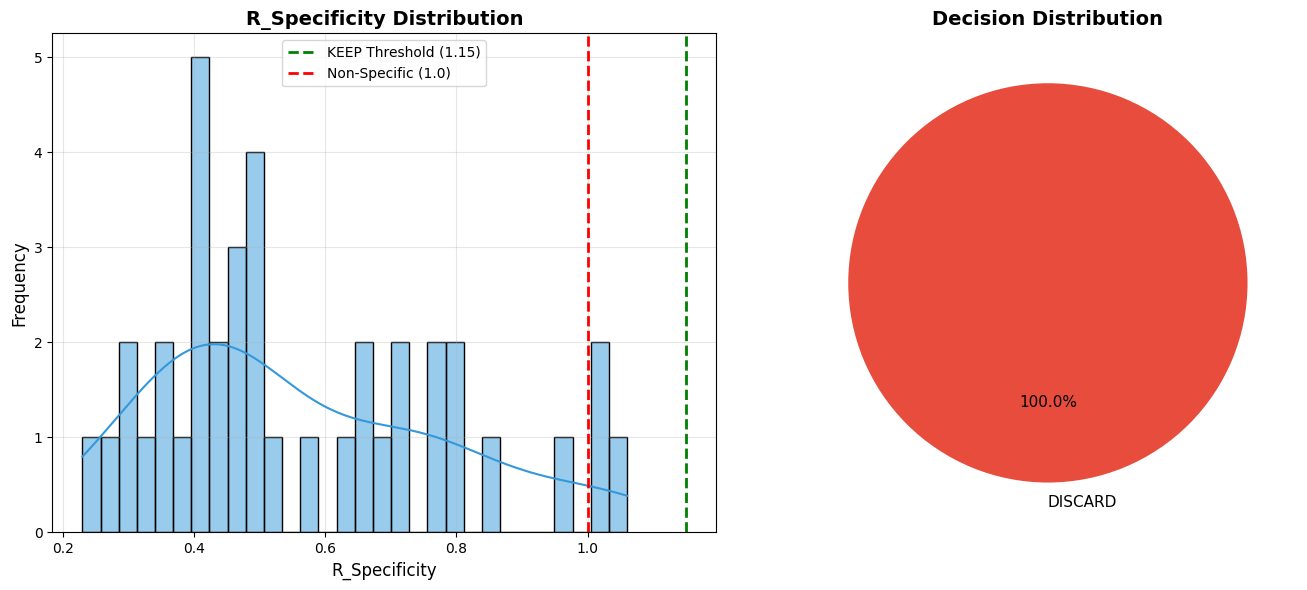


✅ KARAR ALGORİTMASI TAMAMLANDI!

📁 Detaylı rapor için: /home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv
📊 Özet: 0 KEEP, 0 MARGINAL, 39 DISCARD


In [7]:


import pandas as pd
import numpy as np
import re
import os

# --- DOSYA YOLLARI ---
CONFIG = {
    "on_target_csv": "/home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv",
    "off_target_csv": "/home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget/OTR_offtarget_test1.csv",
    "final_report": "/home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/final_candidates_decision.csv",
    
    # --- KARAR EŞİKLERİ ---
    "thresholds": {
        "r_spec_min": 1.15,        # ON-TARGET, OFF-TARGET'tan en az %15 iyi olmalı
        "max_off_score": 0.75,    # OFF-TARGET bu değeri geçerse DISCARD 
        "min_on_score": 0.40,      # ON-TARGET bu değerin altındaysa DISCARD
        "excellent_r_spec": 1.50,  # R_spec bu değerin üzerindeyse "Excellent" etiket
        "marginal_r_spec": 1.05    # R_spec bu değerin altındaysa "Marginal"
    }
}

# --- FONKSİYONLAR ---

def extract_scfv_id(sample_id):
    """
    Sample ID'den scfv_X_Y kısmını çıkarır.
    
    Örnekler:
    - scfv_48_1_cldn4 -> scfv_48_1
    - scfv_55_9_vs_cld8_human -> scfv_55_9
    - scfv_0_8_vs_cld18_2_human -> scfv_0_8
    """
    match = re.search(r'(scfv_\d+_\d+)', str(sample_id))
    if match:
        return match.group(1)
    return "Unknown"


def extract_off_target_name(sample_id):
    """
    OFF-TARGET'ın hangi Claudin'e bağlandığını çıkarır.
    
    Örnekler:
    - scfv_55_9_vs_cld8_human -> CLDN8
    - scfv_0_8_vs_cld18_2_human -> CLDN18.2
    """
    match = re.search(r'vs_(cld\d+(?:_\d+)?)', str(sample_id))
    if match:
        cldn = match.group(1).upper().replace('CLD', 'CLDN').replace('_', '.')
        return cldn
    return "Unknown"


def make_decision(on_score, off_score, r_spec, worst_target, thresholds):
    """
    Antikor adayı için final kararı verir.
    
    Returns:
        tuple: (decision, reasons_list, priority)
    """
    reasons = []
    decision = "MARGINAL"
    priority = 2  # 1=KEEP, 2=MARGINAL, 3=DISCARD
    
    # --- DISCARD KURALLARI (En Katı) ---
    
    # 1. Toksik OFF-TARGET Bağlanması
    if off_score > thresholds['max_off_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Toxic Off-Target: {worst_target} (Score={off_score:.3f})")
        return decision, reasons, priority
    
    # 2. Zayıf ON-TARGET Bağlanması
    if on_score < thresholds['min_on_score']:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Weak On-Target Binding (Score={on_score:.3f} < {thresholds['min_on_score']})")
        return decision, reasons, priority
    
    # 3. Non-Specific (OFF-TARGET daha iyi bağlanıyor!)
    if r_spec < 1.0:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Non-Specific: Binds {worst_target} better than CLDN4 (R={r_spec:.2f})")
        return decision, reasons, priority
    
    # --- KEEP KURALLARI (İyi Adaylar) ---
    
    # 1. Mükemmel Özgüllük
    if r_spec >= thresholds['excellent_r_spec']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Excellent Specificity (R={r_spec:.2f})")
    
    # 2. İyi Özgüllük
    elif r_spec >= thresholds['r_spec_min']:
        decision = "KEEP"
        priority = 1
        reasons.append(f"✅ Good Specificity (R={r_spec:.2f})")
    
    # --- MARGINAL KURALLARI ---
    
    # Düşük Özgüllük Marjı
    elif r_spec >= thresholds['marginal_r_spec']:
        decision = "MARGINAL"
        priority = 2
        reasons.append(f"⚠️ Low Specificity Margin (R={r_spec:.2f})")
    
    else:
        decision = "DISCARD"
        priority = 3
        reasons.append(f"⚠️ Insufficient Specificity (R={r_spec:.2f} < {thresholds['r_spec_min']})")
    
    # Ek Pozitif Özellikler
    if on_score > 0.70:
        reasons.append(f"💪 Strong On-Target (Score={on_score:.3f})")
    
    if off_score < 0.30:
        reasons.append(f"🛡️ Low Off-Target Risk (Max={off_score:.3f})")
    
    return decision, reasons, priority


# --- ANA AKIŞ ---
print("="*80)
print("🛡️ CLDN4 Antibody Candidate Selection - Final Decision Algorithm")
print("="*80)

# 1. Dosya Kontrolü
print("\n📁 Dosya kontrolü yapılıyor...")
for key, path in [("ON-TARGET", CONFIG["on_target_csv"]), 
                   ("OFF-TARGET", CONFIG["off_target_csv"])]:
    if os.path.exists(path):
        print(f"   ✅ {key}: {path}")
    else:
        print(f"   ❌ {key} BULUNAMADI: {path}")
        exit(1)

# 2. Verileri Yükle
print("\n📊 Veriler yükleniyor...")
try:
    df_on = pd.read_csv(CONFIG["on_target_csv"])
    df_off = pd.read_csv(CONFIG["off_target_csv"])
    print(f"   ✅ ON-TARGET: {len(df_on)} model yüklendi")
    print(f"   ✅ OFF-TARGET: {len(df_off)} model yüklendi")
except Exception as e:
    print(f"   ❌ HATA: {e}")
    exit(1)

# 3. ScFv ID'lerini Çıkar
print("\n🔍 ScFv ID'leri çıkarılıyor...")
df_on['ScFv_ID'] = df_on['Sample_ID'].apply(extract_scfv_id)
df_off['ScFv_ID'] = df_off['Sample_ID'].apply(extract_scfv_id)
df_off['Off_Target_CLDN'] = df_off['Sample_ID'].apply(extract_off_target_name)

print(f"   ON-TARGET'ta benzersiz ScFv sayısı: {df_on['ScFv_ID'].nunique()}")
print(f"   OFF-TARGET'ta benzersiz ScFv sayısı: {df_off['ScFv_ID'].nunique()}")

# Örnek ID'ler göster
print(f"\n   Örnek ON-TARGET ScFv ID'ler:")
for sid in df_on['ScFv_ID'].head(3).tolist():
    print(f"      - {sid}")

print(f"\n   Örnek OFF-TARGET ScFv ID'ler:")
for sid, cldn in zip(df_off['ScFv_ID'].head(3), df_off['Off_Target_CLDN'].head(3)):
    print(f"      - {sid} → {cldn}")

# 4. Her ScFv için EN KÖTÜ Off-Target'ı Bul
print("\n⚠️  Her ScFv için EN KÖTÜ (en yüksek skorlu) Off-Target bulunuyor...")
worst_off_targets = df_off.sort_values('Scientific_Score', ascending=False).drop_duplicates('ScFv_ID')
worst_off_targets = worst_off_targets[['ScFv_ID', 'Sample_ID', 'Off_Target_CLDN', 'Scientific_Score']]
worst_off_targets.rename(columns={
    'Scientific_Score': 'Max_Off_Score',
    'Sample_ID': 'Worst_Off_Sample',
    'Off_Target_CLDN': 'Worst_Off_Target'
}, inplace=True)

print(f"   Toplam {len(worst_off_targets)} ScFv için worst off-target bulundu")

# 5. ON-TARGET ile Birleştir
print("\n🔗 ON-TARGET ve OFF-TARGET verileri birleştiriliyor...")
merged = pd.merge(df_on, worst_off_targets, on='ScFv_ID', how='left')

# OFF-TARGET verisi olmayanları 0 kabul et (güvenli - sadece CLDN4'e test edilmiş)
merged['Max_Off_Score'] = merged['Max_Off_Score'].fillna(0.0)
merged['Worst_Off_Target'] = merged['Worst_Off_Target'].fillna("None")
merged['Worst_Off_Sample'] = merged['Worst_Off_Sample'].fillna("N/A")

print(f"   ✅ {len(merged)} ON-TARGET model birleştirildi")
unmatched = merged['Max_Off_Score'].eq(0).sum()
if unmatched > 0:
    print(f"   ℹ️  {unmatched} model için OFF-TARGET verisi yok (güvenli kabul edilir)")

# 6. Karar Algoritmasını Çalıştır
print("\n⚖️  Karar algoritması çalıştırılıyor...")
print(f"   Eşikler:")
print(f"      - R_spec minimum: {CONFIG['thresholds']['r_spec_min']}")
print(f"      - Max Off-Target score: {CONFIG['thresholds']['max_off_score']}")
print(f"      - Min On-Target score: {CONFIG['thresholds']['min_on_score']}")

results = []
for _, row in merged.iterrows():
    scfv_id = row['ScFv_ID']
    s_on = row['Scientific_Score']
    s_off = row['Max_Off_Score']
    
    # R_spec Hesapla
    if s_off < 0.01:
        r_spec = 100.0  # Off-target yoksa çok güvenli
    else:
        r_spec = s_on / s_off
    
    # Karar Ver
    decision, reasons, priority = make_decision(
        s_on, s_off, r_spec, 
        row['Worst_Off_Target'], 
        CONFIG['thresholds']
    )
    
    # Sonuç Satırı
    res_dict = {
        "ScFv_ID": scfv_id,
        "Decision": decision,
        "Priority": priority,
        "R_Specificity": round(r_spec, 2),
        "Score_CLDN4": round(s_on, 3),
        "Score_Max_Off": round(s_off, 3),
        "Worst_Off_Target": row['Worst_Off_Target'],
        "Worst_Off_Sample": row['Worst_Off_Sample'],
        "Decision_Reasons": "; ".join(reasons),
        # ON-TARGET Detayları
        "CLDN4_Matrix_iPTM": round(row.get('Matrix_iPTM', 0), 3),
        "CLDN4_Matrix_PAE": round(row.get('Matrix_PAE', 0), 3),
        "CLDN4_Affinity_dG": round(row.get('Affinity_dG', 0), 3),
        "CLDN4_pTM": round(row.get('pTM', 0), 3),
        "CLDN4_Disorder": round(row.get('Fraction_Disordered', 0), 3),
        # Orijinal Sample ID
        "Original_Sample_ID": row['Sample_ID']
    }
    results.append(res_dict)

# 7. Sonuçları Raporla
final_df = pd.DataFrame(results)

# Sıralama: Priority -> R_Specificity (azalan)
final_df.sort_values(by=['Priority', 'R_Specificity'], ascending=[True, False], inplace=True)

# Output dizinini oluştur
output_dir = os.path.dirname(CONFIG["final_report"])
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n📁 Output dizini oluşturuldu: {output_dir}")

# Kaydet
final_df.to_csv(CONFIG["final_report"], index=False)

# Özet İstatistikler
print("\n" + "="*80)
print("📊 KARAR ÖZETİ")
print("="*80)
decision_counts = final_df['Decision'].value_counts()
for decision, count in decision_counts.items():
    pct = count / len(final_df) * 100
    print(f"   {decision}: {count} aday ({pct:.1f}%)")

print(f"\nToplam Değerlendirilen: {len(final_df)} ScFv")

# En İyi 15 Adayı Göster
print("\n" + "="*80)
print("🏆 EN İYİ 15 ADAY (KEEP)")
print("="*80)
display_cols = ['ScFv_ID', 'Decision', 'R_Specificity', 'Score_CLDN4', 
                'Score_Max_Off', 'Worst_Off_Target', 'Decision_Reasons']
keep_candidates = final_df[final_df['Decision'] == 'KEEP']
if len(keep_candidates) > 0:
    print(keep_candidates[display_cols].head(15).to_string(index=False))
else:
    print("   ⚠️  KEEP kategorisinde aday bulunamadı!")

# MARGINAL Adayları Göster
print("\n" + "="*80)
print("⚠️  MARGINAL ADAYLAR (Sınır Durumları)")
print("="*80)
marginal_candidates = final_df[final_df['Decision'] == 'MARGINAL']
if len(marginal_candidates) > 0:
    print(marginal_candidates[display_cols].head(10).to_string(index=False))
else:
    print("   ℹ️  Marginal aday yok")

# DISCARD Nedenleri Analizi
print("\n" + "="*80)
print("❌ DISCARD NEDENLERİ ANALİZİ")
print("="*80)
discard_df = final_df[final_df['Decision'] == 'DISCARD']
if len(discard_df) > 0:
    # Nedenleri kategorize et
    toxic_count = discard_df['Decision_Reasons'].str.contains('Toxic Off-Target').sum()
    weak_count = discard_df['Decision_Reasons'].str.contains('Weak On-Target').sum()
    nonspecific_count = discard_df['Decision_Reasons'].str.contains('Non-Specific').sum()
    insufficient_count = discard_df['Decision_Reasons'].str.contains('Insufficient Specificity').sum()
    
    print(f"   Toxic Off-Target: {toxic_count}")
    print(f"   Weak On-Target: {weak_count}")
    print(f"   Non-Specific: {nonspecific_count}")
    print(f"   Insufficient Specificity: {insufficient_count}")
    
    # En kötü 5 örnek
    print(f"\n   En Kötü 5 DISCARD Örneği:")
    worst_5 = discard_df.sort_values('R_Specificity').head(5)
    print(worst_5[display_cols].to_string(index=False))

# R_Specificity Dağılımı
print("\n" + "="*80)
print("📈 R_SPECIFICITY DAĞILIMI")
print("="*80)
print(f"   Minimum: {final_df['R_Specificity'].min():.2f}")
print(f"   25th percentile: {final_df['R_Specificity'].quantile(0.25):.2f}")
print(f"   Median: {final_df['R_Specificity'].median():.2f}")
print(f"   75th percentile: {final_df['R_Specificity'].quantile(0.75):.2f}")
print(f"   Maximum: {final_df['R_Specificity'].max():.2f}")
print(f"   Mean: {final_df['R_Specificity'].mean():.2f}")

# En Yüksek R_spec'e Sahip 5 Aday
print("\n" + "="*80)
print("🌟 EN YÜKSEK SPESİFİKLİĞE SAHİP 5 ADAY")
print("="*80)
top_5_spec = final_df.nlargest(5, 'R_Specificity')
print(top_5_spec[display_cols].to_string(index=False))

# Görselleştirme için veri hazırla
print("\n" + "="*80)
print("💾 KAYIT ve GÖRSELLEŞTİRME")
print("="*80)
print(f"✅ Final rapor kaydedildi: {CONFIG['final_report']}")

# Görsel için basit dağılım grafiği
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # R_Specificity Dağılımı
    sns.histplot(final_df['R_Specificity'], bins=30, kde=True, ax=axes[0], color='#3498db')
    axes[0].axvline(CONFIG['thresholds']['r_spec_min'], color='green', 
                    linestyle='--', linewidth=2, label=f"KEEP Threshold ({CONFIG['thresholds']['r_spec_min']})")
    axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Non-Specific (1.0)')
    axes[0].set_xlabel('R_Specificity', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('R_Specificity Distribution', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Decision Dağılımı (Pie Chart)
    decision_colors = {'KEEP': '#2ecc71', 'MARGINAL': '#f39c12', 'DISCARD': '#e74c3c'}
    decision_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                        colors=[decision_colors.get(x, '#95a5a6') for x in decision_counts.index],
                        startangle=90, textprops={'fontsize': 11})
    axes[1].set_ylabel('')
    axes[1].set_title('Decision Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plot_path = CONFIG["final_report"].replace('.csv', '_analysis.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"📊 Analiz grafiği kaydedildi: {plot_path}")
    plt.show()
    
except ImportError:
    print("⚠️  Matplotlib bulunamadı, grafik oluşturulamadı")

print("\n" + "="*80)
print("✅ KARAR ALGORİTMASI TAMAMLANDI!")
print("="*80)
print(f"\n📁 Detaylı rapor için: {CONFIG['final_report']}")
print(f"📊 Özet: {len(keep_candidates)} KEEP, {len(marginal_candidates)} MARGINAL, {len(discard_df)} DISCARD")